In [ ]:
import pypsa

n0 = pypsa.Network(
    "results/postnetworks/elec_s_100_ec_lv1_Co2L-168h_168h_2023_0.07.nc"
)  # baseline
n1 = pypsa.Network(
    "results/postnetworks/co2_v3.nc"
)  # test network, this network has inf allowances for co2 emissions - should be the same as the baseline network
n2 = pypsa.Network(
    "results/postnetworks/co2_v4.nc"
)  # test network, this network has 95% of n0 co2 emissions for the heat sector - should be different from the baseline network

Index(['CO2 pipeline US8 0 <-> US9 0', 'biomass transport US8 0 <-> US9 0',
       'biomass transport US8 0 <-> US0 13'],
      dtype='object', name='name')
Index(['CO2 pipeline US0 13 <-> US8 0', 'biomass transport US0 13 <-> US8 0',
       'biomass transport US9 0 <-> US8 0'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_100_ec_lv1_Co2L-168h_168h_2023_0.07.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['CO2 pipeline US8 0 <-> US9 0', 'biomass transport US8 0 <-> US9 0',
       'biomass transport US8 0 <-> US0 13'],
      dtype='object', name='name')
Index(['CO2 pipeline US0 13 <-> US8 0', 'biomass transport US0 13 <-> US8 0',
       'biomass transport US9 0 <-> US8 0'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network co2_v3.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [ ]:
n0.carriers[n1.carriers.co2_emissions != 0]

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
geothermal,0.1200,#ba91b1,Geothermal,inf,0.0
co2,-1.0000,#123456,co2,inf,0.0
lignite,0.4069,#9e5a01,lignite,inf,0.0


<Axes: xlabel='snapshot'>

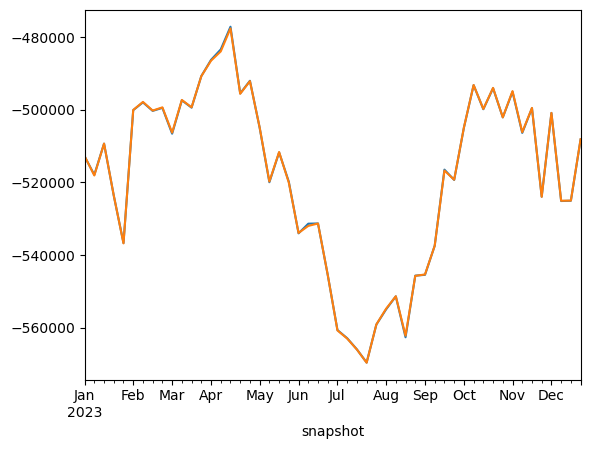

In [ ]:
# overview: check the overall co2 emissions of the networks
n0.stores_t.p["co2 atmosphere"][:-1].plot()
n1.stores_t.p["co2 atmosphere"][:-1].plot()

In [99]:
# get the bus that represents co2 emissions for each carrier type
heat_carriers = [c for c in n0.links.carrier.unique() if "boiler" in c or "CHP" in c]
heat_carrier_co2_bus = {
    c: n0.links[n0.links.carrier == c].columns[
        (n0.links[n0.links.carrier == c] == "co2 atmosphere").any()
    ]
    for c in heat_carriers
}
heat_carrier_co2_bus = {c: b[0] for c, b in heat_carrier_co2_bus.items() if len(b) > 0}

heat_carrier_co2_bus

{'residential rural gas boiler': 'bus2',
 'services rural gas boiler': 'bus2',
 'residential urban decentral gas boiler': 'bus2',
 'services urban decentral gas boiler': 'bus2',
 'urban central gas boiler': 'bus2',
 'urban central gas CHP': 'bus3'}

In [111]:
# get the flow through the relevant co2 links
co2_emissions_total = {}
for c in heat_carrier_co2_bus.keys():
    relevant_links = n0.links[n0.links.carrier == c].index
    p_link = heat_carrier_co2_bus[c][-1]
    co2_emissions_per_carrier = n0.links_t[f"p{p_link}"][relevant_links]
    co2_emissions_total[c] = co2_emissions_per_carrier.sum().sum()

co2_emissions_total

{'residential rural gas boiler': -614.8042384788097,
 'services rural gas boiler': -626.5146397546337,
 'residential urban decentral gas boiler': -1275.8905753477814,
 'services urban decentral gas boiler': -1399.8229157387004,
 'urban central gas boiler': -75351.53336776196,
 'urban central gas CHP': -3409760.1244493774}

In [119]:
co2_emissions_total_all = sum(co2_emissions_total.values())
print(f"total co2 emissions for heat sector: {co2_emissions_total_all} kg")
print(f"reduce by 5% for testing: {co2_emissions_total_all * 0.95} kg")

total co2 emissions for heat sector: -3489028.690186459 kg
reduce by 5% for testing: -3314577.255677136 kg


In [103]:
heat_carriers

['residential rural gas boiler',
 'services rural gas boiler',
 'residential urban decentral gas boiler',
 'services urban decentral gas boiler',
 'urban central gas boiler',
 'urban central gas CHP',
 'urban central solid biomass CHP']